# SPAC perturbation preprocessing and full-chain perturbation-aware FGWUOT alignment

This notebook prepares the SPAC time-course perturbation data for STFateFlow. It merges transcriptome and guide-count AnnData files by spatial coordinate, builds perturbation labels, normalizes gene expression, selects HVGs, standardizes spatial coordinates, and prepares a no-subset alignment chain: Day4_rep1 -> Day7_rep1 -> Day10_rep2.

The alignment cell uses MOSCOT/OTT low-rank fused unbalanced GW on full data. Perturbation awareness is encoded by concatenating scaled expression features with scaled perturbation one-hot features, so squared Euclidean sample cost equals normalized expression cost plus a fixed mismatch penalty for different perturbations, without materializing the full dense cross-time cost or transport matrix.

In [ ]:
from __future__ import annotations

import os
import re
import sys
from pathlib import Path

TMP_ROOT = Path('/data/yuz/tmp')

# Use physical cuda:1 only. Set before importing JAX/MOSCOT; restart the kernel after changing this.
TMP_ROOT.mkdir(parents=True, exist_ok=True)
for _subdir, _env_key in [('numba_cache', 'NUMBA_CACHE_DIR'), ('matplotlib_cache', 'MPLCONFIGDIR')]:
    _p = TMP_ROOT / _subdir
    _p.mkdir(parents=True, exist_ok=True)
    os.environ.setdefault(_env_key, str(_p))
import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import jax
from IPython.display import display

repo_root = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

SEED = 2026
rng = np.random.default_rng(SEED)

print('scanpy:', sc.__version__)
print('repo_root:', repo_root)
print('NUMBA_CACHE_DIR:', os.environ.get('NUMBA_CACHE_DIR'))
print('MPLCONFIGDIR:', os.environ.get('MPLCONFIGDIR'))

scanpy: 1.11.5
repo_root: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow
NUMBA_CACHE_DIR: /data/yuz/tmp/numba_cache
MPLCONFIGDIR: /data/yuz/tmp/matplotlib_cache


/data/yuz/tmp/ipykernel_1532358/1457089352.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print('scanpy:', sc.__version__)


In [ ]:
import jax
jax.devices('gpu')

[CudaDevice(id=0)]

In [2]:
# -----------------------------
# User configurable parameters
# -----------------------------
DATA_ROOT = Path('/data/yuz/perturbation/perturbation_data/SPAC')
TRANSCRIPTOME_DIR = DATA_ROOT / 'Transcriptome'
GUIDE_DIR = DATA_ROOT / 'Perturbation 2'

OUTPUT_DIR = repo_root / 'data' / 'spac'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OT_DIR = OUTPUT_DIR / 'ot_pis'
OT_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_H5AD = OUTPUT_DIR / 'spac_perturbation_preprocessed_hvg2000.h5ad'
LOAD_PREPROCESSED_IF_EXISTS = True

N_TOP_GENES = 2000
MIN_GENES_PER_SPOT = 50
MIN_CELLS_PER_GENE = 20
NORMALIZE_TARGET_SUM = 1e4
STORE_COUNTS_LAYER = False
SPATIAL_NORMALIZATION = 'per_sample'  # 'per_sample' or 'global'

# Full alignment chain requested for SPAC. No random subset is taken.
ALIGNMENT_SAMPLE_IDS = ['Day4_rep1', 'Day7_rep1', 'Day10_rep2']
ALIGNMENT_NAME = 'Day4rep1_Day7rep1_Day10rep2_full'
MAX_SPOTS_PER_TIME_FOR_FGWOT = None

# MOSCOT low-rank perturbation-aware FGWUOT parameters.
# The linear fused-Wasserstein sample cost is computed on concatenated features:
#   [sqrt(lambda_expr / expr_p95) * expression_feature,
#    sqrt(lambda_pert / 2) * one_hot(perturbation)]
# With sq_euclidean this equals lambda_expr * normalized expression distance
# + lambda_pert for different perturbations and +0 for the same perturbation.
ALIGNMENT_METHOD = 'moscot_lowrank_concat_perturbation_fgwuot'
PERTURBATION_KEY = 'perturbation'  # use 'guide_target' for gene-level perturbations
EXPRESSION_FEATURE_KEY = 'X_pca'   # use PCA features for full-data memory; set to 'X' for HVG expression
JOINT_FEATURE_KEY = 'X_joint_perturbation'
EXPRESSION_SCALE_QUANTILE = 95.0
EXPRESSION_SCALE_SAMPLE_PAIRS = 20000
LAMBDA_EXPRESSION = 2.0
LAMBDA_PERTURBATION = 30.0
INCLUDE_SPATIAL_IN_JOINT_FEATURE = False
SPATIAL_LINEAR_KEY = 'X_spatial_input'  # optional; ignored when INCLUDE_SPATIAL_IN_JOINT_FEATURE is False
SPATIAL_LINEAR_SCALE_QUANTILE = 95.0
LAMBDA_SPATIAL_LINEAR = 0.0
# Coordinates are constrained only by the GW structural term through spatial_key.
# Do not include absolute spatial coordinates in joint_attr when slice coordinate systems are not unified.
# MOSCOT/OTT requires alpha in (0, 1]; alpha closer to 1 emphasizes GW structure,
# while smaller alpha strengthens the expression/perturbation linear term.
MOSCOT_ALPHA = 0.80
MOSCOT_EPSILON = 0.0     # OTT recommends 0 for low-rank GW
MOSCOT_TAU_A = 0.97      # <1 makes the marginals unbalanced
MOSCOT_TAU_B = 0.97
MOSCOT_RANK = 1000       # higher rank preserves more local coupling structure; lower if GPU memory is insufficient
MOSCOT_BATCH_SIZE = 4096
MOSCOT_MIN_ITERATIONS = 0
MOSCOT_INNER_ITERATIONS = 1500
# MOSCOT_MAX_ITERATIONS = 5000
MOSCOT_THRESHOLD = 5e-3
MOSCOT_GAMMA = 10.0
MOSCOT_GAMMA_RESCALE = True
MOSCOT_SCALE_COST = 'mean'
MOSCOT_DEVICE = 'gpu'    # set to 'cpu' if JAX cannot see a GPU
RUN_MOSCOT_FULL_ALIGNMENT = False
SAVE_LOW_RANK_FACTORS = True
MAX_TRANSITION_LAG = 1
OT_PLAN_NORMALIZE = False

print('data root:', DATA_ROOT)
print('output dir:', OUTPUT_DIR)
print('processed h5ad:', PROCESSED_H5AD)

data root: /data/yuz/perturbation/perturbation_data/SPAC
output dir: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/spac
processed h5ad: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/spac/spac_perturbation_preprocessed_hvg2000.h5ad


In [3]:
def parse_spac_sample(path: Path) -> dict[str, object]:
    match = re.search(r'Day(?P<day>\d+)_rep(?P<rep>\d+)', path.name)
    if match is None:
        raise ValueError(f'Cannot parse Day/replicate from {path}')
    day = int(match.group('day'))
    rep = int(match.group('rep'))
    return {
        'day': day,
        'time': float(day),
        'replicate': f'rep{rep}',
        'replicate_id': rep,
        'sample_id': f'Day{day}_rep{rep}',
    }

transcriptome_files = {parse_spac_sample(p)['sample_id']: p for p in sorted(TRANSCRIPTOME_DIR.glob('Day*_rep*.h5'))}
guide_files = {parse_spac_sample(p)['sample_id']: p for p in sorted(GUIDE_DIR.glob('Day*_rep*.guide.h5'))}

sample_ids = sorted(set(transcriptome_files).intersection(guide_files), key=lambda s: (parse_spac_sample(Path(s))['day'], parse_spac_sample(Path(s))['replicate_id']))
if not sample_ids:
    raise FileNotFoundError('No matched transcriptome/guide SPAC samples found.')

sample_pairs = []
for sample_id in sample_ids:
    meta = parse_spac_sample(Path(sample_id))
    meta['transcriptome_path'] = transcriptome_files[sample_id]
    meta['guide_path'] = guide_files[sample_id]
    sample_pairs.append(meta)

pairs_df = pd.DataFrame(sample_pairs)
display(pairs_df[['sample_id', 'day', 'time', 'replicate', 'transcriptome_path', 'guide_path']])

,sample_id,day,time,replicate,transcriptome_path,guide_path
0,Day4_rep1,4,4.0,rep1,/data/yuz/perturbation/perturbation_data/SPAC/...,/data/yuz/perturbation/perturbation_data/SPAC/...
1,Day4_rep2,4,4.0,rep2,/data/yuz/perturbation/perturbation_data/SPAC/...,/data/yuz/perturbation/perturbation_data/SPAC/...
2,Day7_rep1,7,7.0,rep1,/data/yuz/perturbation/perturbation_data/SPAC/...,/data/yuz/perturbation/perturbation_data/SPAC/...
3,Day7_rep2,7,7.0,rep2,/data/yuz/perturbation/perturbation_data/SPAC/...,/data/yuz/perturbation/perturbation_data/SPAC/...
4,Day10_rep1,10,10.0,rep1,/data/yuz/perturbation/perturbation_data/SPAC/...,/data/yuz/perturbation/perturbation_data/SPAC/...
5,Day10_rep2,10,10.0,rep2,/data/yuz/perturbation/perturbation_data/SPAC/...,/data/yuz/perturbation/perturbation_data/SPAC/...


In [4]:
def _spatial_frame(adata_obj: ad.AnnData, index_name: str) -> pd.DataFrame:
    spatial = np.asarray(adata_obj.obsm['spatial'])
    if spatial.ndim != 2 or spatial.shape[1] < 2:
        raise ValueError(f'Expected obsm["spatial"] with shape (n, 2+), got {spatial.shape}')
    frame = pd.DataFrame({
        'spatial_x': spatial[:, 0],
        'spatial_y': spatial[:, 1],
        index_name: np.arange(adata_obj.n_obs, dtype=np.int64),
    })
    duplicated = int(frame.duplicated(['spatial_x', 'spatial_y']).sum())
    if duplicated:
        raise ValueError(f'Found {duplicated} duplicated spatial coordinates; update matching logic before merging.')
    return frame


def match_transcriptome_and_guide(transcriptome: ad.AnnData, guide: ad.AnnData) -> pd.DataFrame:
    t_frame = _spatial_frame(transcriptome, 'transcriptome_idx')
    g_frame = _spatial_frame(guide, 'guide_idx')
    matched = t_frame.merge(g_frame, on=['spatial_x', 'spatial_y'], how='inner', validate='one_to_one')
    matched = matched.sort_values('transcriptome_idx').reset_index(drop=True)
    if matched.empty:
        raise ValueError('Transcriptome and guide files have no shared spatial coordinates.')
    return matched


def guide_obs_and_counts(guide: ad.AnnData, guide_indices: np.ndarray) -> tuple[pd.DataFrame, np.ndarray]:
    X = guide.X[guide_indices]
    if sp.issparse(X):
        X = X.toarray()
    X = np.asarray(X)
    guide_names = np.asarray(guide.var_names.astype(str))

    total_counts = X.sum(axis=1)
    n_detected = (X > 0).sum(axis=1)
    if X.shape[1] == 0:
        top_idx = np.zeros(X.shape[0], dtype=np.int64)
        top_counts = np.zeros(X.shape[0], dtype=X.dtype)
        guide_call = np.repeat('no_guide', X.shape[0])
    else:
        top_idx = np.asarray(X.argmax(axis=1)).astype(np.int64)
        top_counts = X[np.arange(X.shape[0]), top_idx]
        guide_call = np.where(top_counts > 0, guide_names[top_idx], 'no_guide')

    guide_target = pd.Series(guide_call, dtype='object').str.replace(r'^sg', '', regex=True)
    guide_target = guide_target.where(guide_call != 'no_guide', 'no_guide')

    obs = pd.DataFrame({
        'guide_barcode': np.asarray(guide.obs_names[guide_indices]).astype(str),
        'guide_call': guide_call.astype(str),
        'guide_target': guide_target.to_numpy(dtype=str),
        'guide_total_counts': np.asarray(total_counts).astype(np.float32),
        'guide_top_count': np.asarray(top_counts).astype(np.float32),
        'guide_n_detected': np.asarray(n_detected).astype(np.int16),
    })
    return obs, X.astype(np.int16, copy=False)


def load_merged_spac_sample(pair: dict[str, object]) -> ad.AnnData:
    sample_id = str(pair['sample_id'])
    transcriptome_path = Path(pair['transcriptome_path'])
    guide_path = Path(pair['guide_path'])

    transcriptome = sc.read_h5ad(transcriptome_path, backed='r')
    guide = sc.read_h5ad(guide_path)
    matched = match_transcriptome_and_guide(transcriptome, guide)

    t_idx = matched['transcriptome_idx'].to_numpy(dtype=np.int64)
    g_idx = matched['guide_idx'].to_numpy(dtype=np.int64)
    sample = transcriptome[t_idx, :].to_memory()
    transcriptome.file.close()

    guide_obs, guide_counts = guide_obs_and_counts(guide, g_idx)
    sample.obs = sample.obs.reset_index(drop=False).rename(columns={'index': 'transcriptome_barcode'})
    sample.obs.index = [f'{sample_id}:{x}' for x in sample.obs['transcriptome_barcode'].astype(str)]
    guide_obs.index = sample.obs.index
    sample.obs = pd.concat([sample.obs, guide_obs], axis=1)

    sample.obs['sample_id'] = sample_id
    sample.obs['day'] = int(pair['day'])
    sample.obs['time'] = float(pair['time'])
    sample.obs['replicate'] = str(pair['replicate'])
    sample.obs['Batch'] = sample_id
    sample.obs['perturbation'] = sample.obs['guide_call'].astype(str)

    for col in ['sample_id', 'replicate', 'Batch', 'guide_call', 'guide_target', 'perturbation']:
        sample.obs[col] = sample.obs[col].astype('category')

    sample.obsm['spatial_raw'] = np.asarray(sample.obsm['spatial'], dtype=np.float32).copy()
    sample.obsm['guide_counts'] = guide_counts
    sample.uns['guide_names'] = np.asarray(guide.var_names.astype(str))
    sample.uns['transcriptome_path'] = str(transcriptome_path)
    sample.uns['guide_path'] = str(guide_path)

    print(
        f'{sample_id}: matched {sample.n_obs:,}/{guide.n_obs:,} guide spots with transcriptome; '
        f'genes={sample.n_vars:,}; guide-positive={(sample.obs["guide_call"].astype(str) != "no_guide").sum():,}'
    )
    return sample

In [ ]:
def standardize_spatial_coordinates(adata_obj: ad.AnnData, mode: str = 'per_sample') -> None:
    raw = np.asarray(adata_obj.obsm['spatial_raw'], dtype=np.float32)
    coords = raw.copy()

    if mode == 'global':
        center = coords.mean(axis=0, keepdims=True)
        scale = np.percentile(np.abs(coords - center), 99, axis=0, keepdims=True)
        scale[scale <= 0] = 1.0
        coords = (coords - center) / scale
    elif mode == 'per_sample':
        for sample_id in adata_obj.obs['sample_id'].astype(str).unique():
            mask = adata_obj.obs['sample_id'].astype(str).to_numpy() == sample_id
            sample_coords = coords[mask]
            center = sample_coords.mean(axis=0, keepdims=True)
            scale = np.percentile(np.abs(sample_coords - center), 99, axis=0, keepdims=True)
            scale[scale <= 0] = 1.0
            coords[mask] = (sample_coords - center) / scale
    else:
        raise ValueError("SPATIAL_NORMALIZATION must be 'per_sample' or 'global'.")

    adata_obj.obsm['X_spatial_input'] = coords.astype(np.float32, copy=False)
    adata_obj.obsm['spatial'] = adata_obj.obsm['X_spatial_input']


def preprocess_spac_adata(sample_pairs: list[dict[str, object]]) -> ad.AnnData:
    sample_adatas = [load_merged_spac_sample(pair) for pair in sample_pairs]
    adata_obj = ad.concat(sample_adatas, axis=0, join='inner', merge='same', uns_merge='first', index_unique=None)
    adata_obj.var_names_make_unique()
    
    if 'n_genes' in adata_obj.obs.columns:
        before = adata_obj.n_obs
        keep = adata_obj.obs['n_genes'].to_numpy() >= MIN_GENES_PER_SPOT
        adata_obj = adata_obj[keep].copy()
        print(f'filtered spots by n_genes >= {MIN_GENES_PER_SPOT}: {before:,} -> {adata_obj.n_obs:,}')

    before_genes = adata_obj.n_vars
    sc.pp.filter_genes(adata_obj, min_cells=MIN_CELLS_PER_GENE)
    print(f'filtered genes by min_cells >= {MIN_CELLS_PER_GENE}: {before_genes:,} -> {adata_obj.n_vars:,}')

    if STORE_COUNTS_LAYER:
        adata_obj.layers['counts'] = adata_obj.X.copy()

    sc.pp.normalize_total(adata_obj, target_sum=NORMALIZE_TARGET_SUM)
    sc.pp.log1p(adata_obj)
    sc.pp.highly_variable_genes(
        adata_obj,
        n_top_genes=N_TOP_GENES,
        batch_key='Batch',
        flavor='seurat',
        subset=False,
    )
    adata_obj = adata_obj[:, adata_obj.var['highly_variable'].to_numpy()].copy()
    print(f'kept HVGs: {adata_obj.n_vars:,}')

    standardize_spatial_coordinates(adata_obj, mode=SPATIAL_NORMALIZATION)
    sc.pp.pca(adata_obj, n_comps=min(50, adata_obj.n_vars - 1), svd_solver='arpack')

    for col in ['time', 'day']:
        adata_obj.obs[col] = adata_obj.obs[col].astype(float)
    for col in ['sample_id', 'replicate', 'Batch', 'guide_call', 'guide_target', 'perturbation']:
        adata_obj.obs[col] = adata_obj.obs[col].astype('category')

    return adata_obj


if LOAD_PREPROCESSED_IF_EXISTS and PROCESSED_H5AD.exists():
    adata = ad.read_h5ad(PROCESSED_H5AD)
    print('Loaded existing preprocessed AnnData:', PROCESSED_H5AD)
else:
    adata = preprocess_spac_adata(sample_pairs)
    adata.write_h5ad(PROCESSED_H5AD, compression='gzip')
    print('Saved preprocessed AnnData:', PROCESSED_H5AD)

print(adata)
print('obs columns:', list(adata.obs.columns))
print('obsm keys:', list(adata.obsm.keys()))
print('timepoints:', sorted(adata.obs['time'].unique().tolist()))
print('replicates:', adata.obs['replicate'].astype(str).unique().tolist())

Loaded existing preprocessed AnnData: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/spac/spac_perturbation_preprocessed_hvg2000.h5ad
AnnData object with n_obs × n_vars = 2103617 × 2000
    obs: 'transcriptome_barcode', 'marker', 'n_genes', 'guide_barcode', 'guide_call', 'guide_target', 'guide_total_counts', 'guide_top_count', 'guide_n_detected', 'sample_id', 'day', 'time', 'replicate', 'Batch', 'perturbation'
    var: 'mt', 'mt-', 'gm', 'Rb', 'rik', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'guide_names', 'guide_path', 'hvg', 'log1p', 'pca', 'transcriptome_path'
    obsm: 'X_pca', 'X_spatial_input', 'guide_counts', 'spatial', 'spatial_raw'
    varm: 'PCs'
obs columns: ['transcriptome_barcode', 'marker', 'n_genes', 'guide_barcode', 'guide_call', 'guide_target', 'guide_total_counts', 'guide_top_count', 'guide_n_detected', 'sample_id', 'day', 'time', '

In [5]:
def make_alignment_chain_adata(adata_obj: ad.AnnData) -> ad.AnnData:
    obs = adata_obj.obs
    missing = [sample_id for sample_id in ALIGNMENT_SAMPLE_IDS if sample_id not in set(obs['sample_id'].astype(str))]
    if missing:
        raise ValueError(f'Missing requested sample_id values in adata.obs["sample_id"]: {missing}')

    selected_idx = []
    for sample_id in ALIGNMENT_SAMPLE_IDS:
        idx = np.flatnonzero(obs['sample_id'].astype(str).to_numpy() == sample_id)
        if idx.size == 0:
            raise ValueError(f'No spots found for {sample_id}')
        selected_idx.append(idx)
        time_values = sorted(np.unique(obs.iloc[idx]['time'].to_numpy(dtype=float)).tolist())
        replicate_values = sorted(obs.iloc[idx]['replicate'].astype(str).unique().tolist())
        print(f'{sample_id}: selected full sample with {idx.size:,} spots; time={time_values}; replicate={replicate_values}')

    selected_idx = np.concatenate(selected_idx)
    alignment_adata = adata_obj[selected_idx].copy()
    alignment_adata.obs['time'] = alignment_adata.obs['time'].astype(float)
    alignment_adata.obs['sample_id'] = alignment_adata.obs['sample_id'].astype('category')
    alignment_adata.obs['replicate'] = alignment_adata.obs['replicate'].astype('category')
    alignment_adata.obsm['spatial'] = np.asarray(alignment_adata.obsm['X_spatial_input'], dtype=np.float32)

    order = {sample_id: i for i, sample_id in enumerate(ALIGNMENT_SAMPLE_IDS)}
    alignment_adata.obs['alignment_order'] = alignment_adata.obs['sample_id'].astype(str).map(order).astype(int)
    alignment_adata.uns['alignment_sample_ids'] = list(ALIGNMENT_SAMPLE_IDS)
    alignment_adata.uns['alignment_name'] = ALIGNMENT_NAME
    return alignment_adata


alignment_h5ad = OUTPUT_DIR / f'spac_perturbation_{ALIGNMENT_NAME}_hvg{N_TOP_GENES}.h5ad'
if alignment_h5ad.exists():
    print('Full alignment-chain h5ad already exists:', alignment_h5ad)
else:
    adata_fgw = make_alignment_chain_adata(adata)
    adata_fgw.write_h5ad(alignment_h5ad, compression='gzip')
    print('Saved full alignment-chain h5ad:', alignment_h5ad, adata_fgw.shape)

alignment_h5ad_by_name = {ALIGNMENT_NAME: alignment_h5ad}
alignment_h5ad_by_name

Full alignment-chain h5ad already exists: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/spac/spac_perturbation_Day4rep1_Day7rep1_Day10rep2_full_hvg2000.h5ad


{'Day4rep1_Day7rep1_Day10rep2_full': PosixPath('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/spac/spac_perturbation_Day4rep1_Day7rep1_Day10rep2_full_hvg2000.h5ad')}

In [8]:
adata = sc.read_h5ad(alignment_h5ad)

In [20]:
adata[adata.obs['guide_target'] == 'non-targeting'].obsm['guide_counts']

ArrayView([[0, 0, 0, ..., 0, 0, 1],
           [0, 0, 0, ..., 1, 0, 3],
           [0, 0, 0, ..., 0, 0, 1],
           ...,
           [0, 0, 0, ..., 0, 0, 1],
           [0, 0, 0, ..., 0, 0, 1],
           [0, 0, 0, ..., 0, 0, 1]], shape=(2602, 34), dtype=int16)

In [19]:
import json
from collections.abc import Mapping

import jax
from moscot.problems.spatiotemporal import SpatioTemporalProblem


def _as_float32_array(x) -> np.ndarray:
    if sp.issparse(x):
        x = x.toarray()
    return np.asarray(x, dtype=np.float32)


def get_expression_features(adata_obj: ad.AnnData, feature_key: str = EXPRESSION_FEATURE_KEY) -> np.ndarray:
    if feature_key == 'X':
        return _as_float32_array(adata_obj.X)
    if feature_key not in adata_obj.obsm:
        raise KeyError(f'{feature_key!r} not found in adata.obsm. Available keys: {list(adata_obj.obsm.keys())}')
    return _as_float32_array(adata_obj.obsm[feature_key])


def _positive_percentile_scale(values: np.ndarray, q: float) -> float:
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    positive = values[values > 0]
    if positive.size == 0:
        return 1.0
    scale = float(np.percentile(positive, q))
    if not np.isfinite(scale) or scale <= 0:
        return 1.0
    return scale


def estimate_cross_time_expression_scale(
    features: np.ndarray,
    obs: pd.DataFrame,
    q: float = EXPRESSION_SCALE_QUANTILE,
    max_pairs: int = EXPRESSION_SCALE_SAMPLE_PAIRS,
    random_state: int = SEED,
) -> float:
    times = obs['time'].to_numpy(dtype=float)
    time_values = sorted(np.unique(times).tolist())
    transitions = list(zip(time_values[:-1], time_values[1:]))
    if not transitions:
        return 1.0

    rng_local = np.random.default_rng(random_state)
    per_transition = max(1, int(np.ceil(max_pairs / len(transitions))))
    sampled_costs: list[np.ndarray] = []
    for timea, timeb in transitions:
        ia = np.flatnonzero(np.isclose(times, float(timea)))
        ib = np.flatnonzero(np.isclose(times, float(timeb)))
        if ia.size == 0 or ib.size == 0:
            continue
        n = min(per_transition, max(ia.size, ib.size))
        src = rng_local.choice(ia, size=n, replace=ia.size < n)
        tgt = rng_local.choice(ib, size=n, replace=ib.size < n)
        diff = features[src] - features[tgt]
        sampled_costs.append(np.einsum('ij,ij->i', diff, diff, optimize=True))
    if not sampled_costs:
        return 1.0
    return _positive_percentile_scale(np.concatenate(sampled_costs), q)


def build_concat_expression_perturbation_features(
    adata_obj: ad.AnnData,
    expression_feature_key: str = EXPRESSION_FEATURE_KEY,
    perturbation_key: str = PERTURBATION_KEY,
    joint_feature_key: str = JOINT_FEATURE_KEY,
) -> dict[str, object]:
    expr = get_expression_features(adata_obj, expression_feature_key)
    expr_scale = estimate_cross_time_expression_scale(expr, adata_obj.obs)
    expr_scaled = expr * np.float32(np.sqrt(float(LAMBDA_EXPRESSION) / expr_scale))
    feature_blocks = [expr_scaled]

    spatial_scale = None
    n_spatial_features = 0
    if INCLUDE_SPATIAL_IN_JOINT_FEATURE:
        if SPATIAL_LINEAR_KEY not in adata_obj.obsm:
            raise KeyError(f'{SPATIAL_LINEAR_KEY!r} not found in adata.obsm for spatial linear anchor.')
        spatial_features = _as_float32_array(adata_obj.obsm[SPATIAL_LINEAR_KEY])
        spatial_scale = estimate_cross_time_expression_scale(
            spatial_features,
            adata_obj.obs,
            q=SPATIAL_LINEAR_SCALE_QUANTILE,
            max_pairs=EXPRESSION_SCALE_SAMPLE_PAIRS,
            random_state=SEED + 17,
        )
        spatial_scaled = spatial_features * np.float32(np.sqrt(float(LAMBDA_SPATIAL_LINEAR) / spatial_scale))
        feature_blocks.append(spatial_scaled)
        n_spatial_features = int(spatial_features.shape[1])

    labels = adata_obj.obs[perturbation_key].astype(str).fillna('unknown').to_numpy()
    categories = np.array(sorted(pd.unique(labels).tolist()), dtype=object)
    cat_to_idx = {str(cat): i for i, cat in enumerate(categories)}
    codes = np.fromiter((cat_to_idx[str(label)] for label in labels), dtype=np.int64, count=labels.size)
    one_hot = np.zeros((adata_obj.n_obs, categories.size), dtype=np.float32)
    one_hot[np.arange(adata_obj.n_obs), codes] = np.float32(np.sqrt(float(LAMBDA_PERTURBATION) / 2.0))

    feature_blocks.append(one_hot)
    adata_obj.obsm[joint_feature_key] = np.concatenate(feature_blocks, axis=1).astype(np.float32, copy=False)
    metadata = {
        'joint_feature_key': joint_feature_key,
        'expression_feature_key': expression_feature_key,
        'perturbation_key': perturbation_key,
        'expression_scale': float(expr_scale),
        'expression_scale_quantile': float(EXPRESSION_SCALE_QUANTILE),
        'lambda_expression': float(LAMBDA_EXPRESSION),
        'lambda_perturbation': float(LAMBDA_PERTURBATION),
        'include_spatial_in_joint_feature': bool(INCLUDE_SPATIAL_IN_JOINT_FEATURE),
        'spatial_linear_key': SPATIAL_LINEAR_KEY if INCLUDE_SPATIAL_IN_JOINT_FEATURE else None,
        'spatial_linear_scale': None if spatial_scale is None else float(spatial_scale),
        'spatial_linear_scale_quantile': float(SPATIAL_LINEAR_SCALE_QUANTILE),
        'lambda_spatial_linear': float(LAMBDA_SPATIAL_LINEAR),
        'perturbation_categories': [str(x) for x in categories.tolist()],
        'n_expression_features': int(expr.shape[1]),
        'n_spatial_features': int(n_spatial_features),
        'n_perturbation_features': int(categories.size),
    }
    adata_obj.uns[f'{joint_feature_key}_params'] = metadata
    return metadata


def _transition_prefix(timea: float, timeb: float) -> str:
    return f'transition_{float(timea):g}_{float(timeb):g}'


def _to_numpy_float32(x) -> np.ndarray:
    return np.asarray(jax.device_get(x), dtype=np.float32)


def extract_low_rank_factors(solution) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    output = getattr(solution, '_output', solution)
    candidates = [output, getattr(output, 'linear_state', None)]
    for candidate in candidates:
        if candidate is None:
            continue
        if all(hasattr(candidate, attr) for attr in ('q', 'r', 'g')):
            q = _to_numpy_float32(candidate.q)
            r = _to_numpy_float32(candidate.r)
            g = _to_numpy_float32(candidate.g)
            if q.ndim != 2 or r.ndim != 2 or g.ndim != 1:
                raise ValueError(f'Unexpected low-rank factor shapes: q={q.shape}, r={r.shape}, g={g.shape}')
            return q, r, g
    raise TypeError(
        'Could not find low-rank q/r/g factors in the MOSCOT solution. '
        'Make sure solve(..., rank=MOSCOT_RANK) uses rank > 0 and avoid accessing transport_matrix.'
    )



def extract_solution_diagnostics(solution) -> tuple[dict[str, object], dict[str, np.ndarray]]:
    output = getattr(solution, '_output', solution)
    diagnostics: dict[str, object] = {}
    arrays: dict[str, np.ndarray] = {}
    converged = getattr(output, 'converged', None)
    if converged is not None:
        diagnostics['converged'] = bool(np.asarray(jax.device_get(converged)).item())
    for name in ['n_iters', 'inner_iterations']:
        value = getattr(output, name, None)
        if value is not None:
            arr = np.asarray(jax.device_get(value))
            if arr.size == 1:
                diagnostics[name] = int(arr.item())
    for name in ['errors', 'costs']:
        value = getattr(output, name, None)
        if value is not None:
            arr = np.asarray(jax.device_get(value), dtype=np.float64)
            arrays[name] = arr
            finite = arr[np.isfinite(arr)]
            if finite.size:
                diagnostics[f'{name}_last'] = float(finite[-1])
                diagnostics[f'{name}_min'] = float(finite.min())
    return diagnostics, arrays

def save_moscot_low_rank_factors(problem: SpatioTemporalProblem, path: Path, metadata: Mapping[str, object]) -> Path:
    arrays: dict[str, np.ndarray] = {}
    transitions_meta: list[dict[str, object]] = []
    for (timea, timeb), solution in problem.solutions.items():
        q, r, g = extract_low_rank_factors(solution)
        prefix = _transition_prefix(timea, timeb)
        arrays[f'{prefix}_q'] = q
        arrays[f'{prefix}_r'] = r
        arrays[f'{prefix}_g'] = g
        diagnostics, diagnostic_arrays = extract_solution_diagnostics(solution)
        for diagnostic_name, diagnostic_array in diagnostic_arrays.items():
            arrays[f'{prefix}_{diagnostic_name}'] = diagnostic_array
        transition_meta = {
            'prefix': prefix,
            'source_time': float(timea),
            'target_time': float(timeb),
            'q_shape': list(q.shape),
            'r_shape': list(r.shape),
            'g_shape': list(g.shape),
            'factor_mass': float((q.sum(axis=0) * r.sum(axis=0) / np.maximum(g, 1e-12)).sum()),
        }
        transition_meta.update(diagnostics)
        transitions_meta.append(transition_meta)
    full_metadata = dict(metadata)
    full_metadata.update({
        'alignment_method': ALIGNMENT_METHOD,
        'alignment_name': ALIGNMENT_NAME,
        'moscot_alpha': float(MOSCOT_ALPHA),
        'moscot_epsilon': float(MOSCOT_EPSILON),
        'moscot_tau_a': float(MOSCOT_TAU_A),
        'moscot_tau_b': float(MOSCOT_TAU_B),
        'moscot_rank': int(MOSCOT_RANK),
        'moscot_batch_size': None if MOSCOT_BATCH_SIZE is None else int(MOSCOT_BATCH_SIZE),
        'moscot_min_iterations': None if MOSCOT_MIN_ITERATIONS is None else int(MOSCOT_MIN_ITERATIONS),
        'moscot_inner_iterations': None if MOSCOT_INNER_ITERATIONS is None else int(MOSCOT_INNER_ITERATIONS),
        # 'moscot_max_iterations': None if MOSCOT_MAX_ITERATIONS is None else int(MOSCOT_MAX_ITERATIONS),
        'moscot_threshold': float(MOSCOT_THRESHOLD),
        'moscot_gamma': float(MOSCOT_GAMMA),
        'moscot_gamma_rescale': bool(MOSCOT_GAMMA_RESCALE),
        'moscot_scale_cost': MOSCOT_SCALE_COST,
        'moscot_device': MOSCOT_DEVICE,
        'transitions': transitions_meta,
    })
    arrays['metadata_json'] = np.array(json.dumps(full_metadata, ensure_ascii=False))
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(path, **arrays)
    return path


def compute_and_save_moscot_concat_fgwuot(
    adata_for_moscot: ad.AnnData,
    alignment_name: str,
    spatial_key: str = 'X_spatial_input',
) -> tuple[Path, SpatioTemporalProblem | None]:
    if MOSCOT_RANK <= 0:
        raise ValueError('Use MOSCOT_RANK > 0 to keep the full-data transport plan in low-rank factor form.')

    spatial_tag = f'spatial{LAMBDA_SPATIAL_LINEAR:g}' if INCLUDE_SPATIAL_IN_JOINT_FEATURE else 'nospatial'
    factor_cache_path = OT_DIR / (
        f'{alignment_name}_moscot_lowrank_concatpert_'
        f'{EXPRESSION_FEATURE_KEY}_{spatial_tag}_rank{MOSCOT_RANK}_alpha{MOSCOT_ALPHA:g}_'
        f'tau{MOSCOT_TAU_A:g}-{MOSCOT_TAU_B:g}_lambdaPert{LAMBDA_PERTURBATION:g}_'
        f'inner{MOSCOT_INNER_ITERATIONS}_thr{MOSCOT_THRESHOLD:g}.npz'
    )
    if factor_cache_path.exists():
        print('MOSCOT low-rank factor cache already exists:', factor_cache_path)
        return factor_cache_path, None

    print('JAX devices:', jax.devices())
    print(f'Building concatenated expression+perturbation features in obsm[{JOINT_FEATURE_KEY!r}] ...', flush=True)
    feature_metadata = build_concat_expression_perturbation_features(adata_for_moscot)
    print('joint feature shape:', adata_for_moscot.obsm[JOINT_FEATURE_KEY].shape, flush=True)
    print('feature metadata:', feature_metadata, flush=True)

    problem = SpatioTemporalProblem(adata_for_moscot)
    problem = problem.prepare(
        time_key='time',
        spatial_key=spatial_key,
        joint_attr={'attr': 'obsm', 'key': JOINT_FEATURE_KEY},
        normalize_spatial=False,
        policy='sequential',
        cost={'xy': 'sq_euclidean', 'x': 'sq_euclidean', 'y': 'sq_euclidean'},
    )
    problem = problem.solve(
        alpha=MOSCOT_ALPHA,
        epsilon=MOSCOT_EPSILON,
        tau_a=MOSCOT_TAU_A,
        tau_b=MOSCOT_TAU_B,
        rank=MOSCOT_RANK,
        scale_cost=MOSCOT_SCALE_COST,
        batch_size=MOSCOT_BATCH_SIZE,
        min_iterations=MOSCOT_MIN_ITERATIONS,
        inner_iterations=MOSCOT_INNER_ITERATIONS,
        # max_iterations=MOSCOT_MAX_ITERATIONS,
        threshold=MOSCOT_THRESHOLD,
        gamma=MOSCOT_GAMMA,
        gamma_rescale=MOSCOT_GAMMA_RESCALE,
        device=MOSCOT_DEVICE,
    )
    save_moscot_low_rank_factors(problem, factor_cache_path, feature_metadata)
    print('Saved MOSCOT low-rank factor cache:', factor_cache_path, flush=True)
    return factor_cache_path, problem


alignment_name = ALIGNMENT_NAME
fgw_h5ad = alignment_h5ad_by_name[alignment_name]
moscot_factor_cache_by_replicate: dict[str, Path] = {}
moscot_problem_by_replicate: dict[str, SpatioTemporalProblem | None] = {}
RUN_MOSCOT_FULL_ALIGNMENT = True
if RUN_MOSCOT_FULL_ALIGNMENT:
    print(f'Computing full perturbation-aware FGWUOT with MOSCOT for {alignment_name}')
    adata_moscot = ad.read_h5ad(fgw_h5ad)
    factor_cache_path, problem = compute_and_save_moscot_concat_fgwuot(adata_moscot, alignment_name)
    moscot_factor_cache_by_replicate[alignment_name] = factor_cache_path
    moscot_problem_by_replicate[alignment_name] = problem
else:
    spatial_tag = f'spatial{LAMBDA_SPATIAL_LINEAR:g}' if INCLUDE_SPATIAL_IN_JOINT_FEATURE else 'nospatial'
    factor_cache_path = OT_DIR / (
        f'{alignment_name}_moscot_lowrank_concatpert_'
        f'{EXPRESSION_FEATURE_KEY}_{spatial_tag}_rank{MOSCOT_RANK}_alpha{MOSCOT_ALPHA:g}_'
        f'tau{MOSCOT_TAU_A:g}-{MOSCOT_TAU_B:g}_lambdaPert{LAMBDA_PERTURBATION:g}_'
        f'inner{MOSCOT_INNER_ITERATIONS}_thr{MOSCOT_THRESHOLD:g}.npz'
    )
    moscot_factor_cache_by_replicate[alignment_name] = factor_cache_path
    print('MOSCOT full alignment is configured but not launched.')
    print('Set RUN_MOSCOT_FULL_ALIGNMENT = True and run this cell on a GPU-visible JAX environment.')
    print('Expected low-rank factor cache:', factor_cache_path)


Computing full perturbation-aware FGWUOT with MOSCOT for Day4rep1_Day7rep1_Day10rep2_full
JAX devices: [CudaDevice(id=0)]
Building concatenated expression+perturbation features in obsm['X_joint_perturbation'] ...
joint feature shape: (1300313, 85)
feature metadata: {'joint_feature_key': 'X_joint_perturbation', 'expression_feature_key': 'X_pca', 'perturbation_key': 'perturbation', 'expression_scale': 433.6154113769531, 'expression_scale_quantile': 95.0, 'lambda_expression': 2.0, 'lambda_perturbation': 30.0, 'include_spatial_in_joint_feature': False, 'spatial_linear_key': None, 'spatial_linear_scale': None, 'spatial_linear_scale_quantile': 95.0, 'lambda_spatial_linear': 0.0, 'perturbation_categories': ['no_guide', 'sgAdrb2', 'sgAqp3', 'sgArntl', 'sgCd44', 'sgCd52', 'sgCxcl16', 'sgDdit3', 'sgErgic2', 'sgFbxo7', 'sgFlot1', 'sgGata3', 'sgGlb1l2', 'sgGpa33', 'sgIkbip', 'sgKcna3', 'sgKlrd1', 'sgL3mbtl3', 'sgMark3', 'sgMcoln1', 'sgNmb', 'sgPiezo1', 'sgPomt1', 'sgPpia', 'sgS100a11', 'sgScamp4',

In [20]:
import json


def load_moscot_lowrank_factor_cache(path: Path) -> tuple[dict[tuple[float, float], dict[str, np.ndarray]], dict[str, object]]:
    cached = np.load(path, allow_pickle=False)
    if 'metadata_json' not in cached.files:
        raise ValueError(f'metadata_json not found in {path}')
    metadata = json.loads(str(cached['metadata_json'].item()))
    factors: dict[tuple[float, float], dict[str, np.ndarray]] = {}
    for transition in metadata.get('transitions', []):
        prefix = transition['prefix']
        timea = float(transition['source_time'])
        timeb = float(transition['target_time'])
        q = np.asarray(cached[f'{prefix}_q'], dtype=np.float32)
        r = np.asarray(cached[f'{prefix}_r'], dtype=np.float32)
        g = np.asarray(cached[f'{prefix}_g'], dtype=np.float32)
        factors[(timea, timeb)] = {'q': q, 'r': r, 'g': g}
    if not factors:
        raise ValueError(f'No low-rank transitions found in {path}')
    return factors, metadata


def _weighted_choice_from_nonnegative(weights: np.ndarray, size: int, rng_obj: np.random.Generator) -> np.ndarray:
    weights = np.asarray(weights, dtype=np.float64)
    weights = np.clip(weights, a_min=0.0, a_max=None)
    total = float(weights.sum())
    if total <= 0 or not np.isfinite(total):
        weights = np.ones(weights.shape[0], dtype=np.float64) / max(weights.shape[0], 1)
        total = float(weights.sum())
    cdf = np.cumsum(weights)
    draws = rng_obj.random(size) * cdf[-1]
    return np.searchsorted(cdf, draws, side='right')


def sample_lowrank_coupling_pairs(
    q: np.ndarray,
    r: np.ndarray,
    g: np.ndarray,
    n_pairs: int,
    rng_obj: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    q = np.clip(np.asarray(q, dtype=np.float64), a_min=0.0, a_max=None)
    r = np.clip(np.asarray(r, dtype=np.float64), a_min=0.0, a_max=None)
    g = np.maximum(np.asarray(g, dtype=np.float64), 1e-12)
    q_sum = q.sum(axis=0)
    r_sum = r.sum(axis=0)
    component_weights = q_sum * r_sum / g
    components = _weighted_choice_from_nonnegative(component_weights, n_pairs, rng_obj)
    source_idx = np.empty(n_pairs, dtype=np.int64)
    target_idx = np.empty(n_pairs, dtype=np.int64)
    for k in np.unique(components):
        mask = components == k
        source_idx[mask] = _weighted_choice_from_nonnegative(q[:, k], int(mask.sum()), rng_obj)
        target_idx[mask] = _weighted_choice_from_nonnegative(r[:, k], int(mask.sum()), rng_obj)
    return source_idx, target_idx


def sample_lowrank_targets_for_sources(
    q: np.ndarray,
    r: np.ndarray,
    g: np.ndarray,
    source_indices: np.ndarray,
    rng_obj: np.random.Generator,
) -> np.ndarray:
    q = np.clip(np.asarray(q, dtype=np.float64), a_min=0.0, a_max=None)
    r = np.clip(np.asarray(r, dtype=np.float64), a_min=0.0, a_max=None)
    g = np.maximum(np.asarray(g, dtype=np.float64), 1e-12)
    r_sum = r.sum(axis=0)
    source_indices = np.asarray(source_indices, dtype=np.int64)
    target_idx = np.empty(source_indices.size, dtype=np.int64)
    for out_pos, src in enumerate(source_indices):
        component_weights = q[src, :] * r_sum / g
        k = int(_weighted_choice_from_nonnegative(component_weights, 1, rng_obj)[0])
        target_idx[out_pos] = int(_weighted_choice_from_nonnegative(r[:, k], 1, rng_obj)[0])
    return target_idx


def summarize_sampled_lowrank_alignment(
    adata_obj: ad.AnnData,
    factors_by_transition: dict[tuple[float, float], dict[str, np.ndarray]],
    n_pairs: int = 50000,
    rng_seed: int = SEED,
) -> pd.DataFrame:
    rng_diag = np.random.default_rng(rng_seed)
    obs = adata_obj.obs
    times = obs['time'].to_numpy(dtype=float)
    rows: list[dict[str, object]] = []
    for (timea, timeb), factors in sorted(factors_by_transition.items()):
        src_idx, tgt_idx = sample_lowrank_coupling_pairs(factors['q'], factors['r'], factors['g'], n_pairs, rng_diag)
        source_mask = np.isclose(times, float(timea))
        target_mask = np.isclose(times, float(timeb))
        source_labels = obs.loc[source_mask, PERTURBATION_KEY].astype(str).to_numpy()[src_idx]
        target_labels = obs.loc[target_mask, PERTURBATION_KEY].astype(str).to_numpy()[tgt_idx]
        source_spatial = np.asarray(adata_obj.obsm['X_spatial_input'][source_mask], dtype=np.float32)[src_idx]
        target_spatial = np.asarray(adata_obj.obsm['X_spatial_input'][target_mask], dtype=np.float32)[tgt_idx]
        spatial_dist = np.sqrt(np.sum((source_spatial - target_spatial) ** 2, axis=1))
        source_perturbed = source_labels != 'no_guide'
        for label, mask in [('all', np.ones(source_labels.shape[0], dtype=bool)), ('perturbed_source', source_perturbed)]:
            if not np.any(mask):
                continue
            rows.append({
                'transition': f'{timea:g}->{timeb:g}',
                'subset': label,
                'n_pairs': int(mask.sum()),
                'same_perturbation_fraction': float(np.mean(source_labels[mask] == target_labels[mask])),
                'target_no_guide_fraction': float(np.mean(target_labels[mask] == 'no_guide')),
                'median_spatial_distance': float(np.median(spatial_dist[mask])),
                'p90_spatial_distance': float(np.quantile(spatial_dist[mask], 0.9)),
            })
    return pd.DataFrame(rows)


alignment_for_training = ALIGNMENT_NAME
adata_train = ad.read_h5ad(alignment_h5ad_by_name[alignment_for_training])
timepoints_ordered = sorted(adata_train.obs['time'].unique().tolist())
timepoint_col = 'time'
cell_type_col = PERTURBATION_KEY
coord_obsm_key = 'X_spatial_input'
adata_train.obsm['spatial'] = np.asarray(adata_train.obsm[coord_obsm_key], dtype=np.float32)

factor_cache_path = moscot_factor_cache_by_replicate.get(alignment_for_training)
lowrank_factors: dict[tuple[float, float], dict[str, np.ndarray]] = {}
lowrank_metadata: dict[str, object] = {}
if factor_cache_path is not None and factor_cache_path.exists():
    lowrank_factors, lowrank_metadata = load_moscot_lowrank_factor_cache(factor_cache_path)
    print('Loaded MOSCOT low-rank factor cache:', factor_cache_path)
    print('transitions:', sorted(lowrank_factors.keys()))
    print('example factor shapes:', {k: v.shape for k, v in next(iter(lowrank_factors.values())).items()})
    if lowrank_metadata.get('transitions'):
        display(pd.DataFrame(lowrank_metadata['transitions']))
    display(summarize_sampled_lowrank_alignment(adata_train, lowrank_factors))
else:
    print('MOSCOT low-rank factor cache is not available yet:', factor_cache_path)
    print('Run the MOSCOT alignment cell with RUN_MOSCOT_FULL_ALIGNMENT = True before training/sampling.')

print('alignment_for_training:', alignment_for_training)
print('adata_train:', adata_train)
print('timepoints_ordered:', timepoints_ordered)
print('cell_type_col:', cell_type_col)
print('Use lowrank_factors for sampling; do not materialize solution.transport_matrix on full data.')


Loaded MOSCOT low-rank factor cache: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/spac/ot_pis/Day4rep1_Day7rep1_Day10rep2_full_moscot_lowrank_concatpert_X_pca_nospatial_rank1000_alpha0.8_tau0.97-0.97_lambdaPert30_inner1500_thr0.005.npz
transitions: [(4.0, 7.0), (7.0, 10.0)]
example factor shapes: {'q': (535339, 1000), 'r': (268551, 1000), 'g': (1000,)}


,prefix,source_time,target_time,q_shape,r_shape,g_shape,factor_mass,converged,n_iters,inner_iterations,errors_last,errors_min,costs_last,costs_min
0,transition_7_10,7.0,10.0,"[535339, 1000]","[268551, 1000]",[1000],0.994615,True,4500,1500,-1.0,-1.0,-1.0,-1.0
1,transition_4_7,4.0,7.0,"[496423, 1000]","[535339, 1000]",[1000],0.994591,True,4500,1500,-1.0,-1.0,-1.0,-1.0


,transition,subset,n_pairs,same_perturbation_fraction,target_no_guide_fraction,median_spatial_distance,p90_spatial_distance
0,4->7,all,50000,0.942160,0.937700,0.827453,1.818781
1,4->7,perturbed_source,3170,0.088959,0.018612,0.785586,1.722982
2,7->10,all,50000,0.947080,0.941600,0.884712,1.307897
3,7->10,perturbed_source,3012,0.121514,0.030544,0.858496,1.334855


alignment_for_training: Day4rep1_Day7rep1_Day10rep2_full
adata_train: AnnData object with n_obs × n_vars = 1300313 × 2000
    obs: 'transcriptome_barcode', 'marker', 'n_genes', 'guide_barcode', 'guide_call', 'guide_target', 'guide_total_counts', 'guide_top_count', 'guide_n_detected', 'sample_id', 'day', 'time', 'replicate', 'Batch', 'perturbation', 'alignment_order'
    var: 'mt', 'mt-', 'gm', 'Rb', 'rik', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'alignment_name', 'alignment_sample_ids', 'guide_names', 'guide_path', 'hvg', 'log1p', 'pca', 'transcriptome_path'
    obsm: 'X_pca', 'X_spatial_input', 'guide_counts', 'spatial', 'spatial_raw'
    varm: 'PCs'
timepoints_ordered: [4.0, 7.0, 10.0]
cell_type_col: perturbation
Use lowrank_factors for sampling; do not materialize solution.transport_matrix on full data.


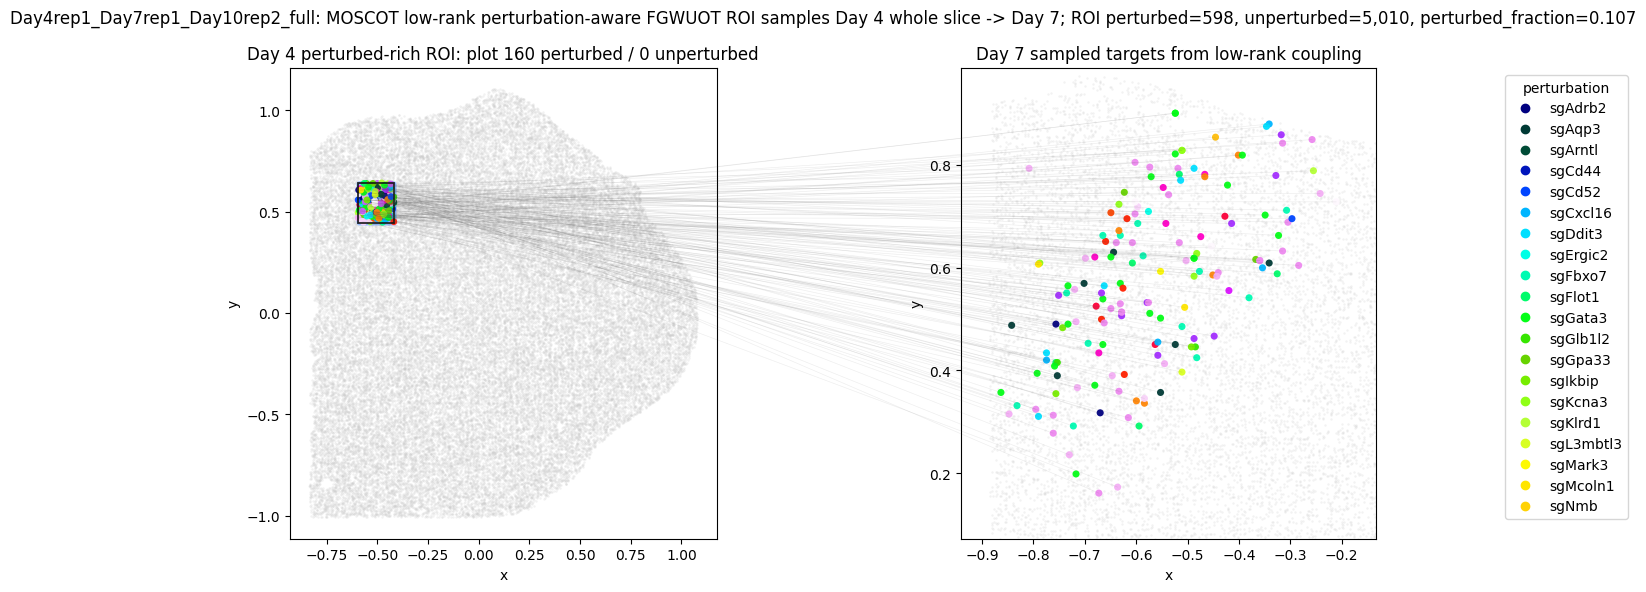

In [21]:
# Local low-rank MOSCOT alignment visualization for a simple perturbed-cell-rich source ROI.
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch, Rectangle
from matplotlib.lines import Line2D

source_timepoint = 4.0
target_timepoint = 7.0
source_guide = None  # e.g. 'sgGeneX'; keep None to search all source spots.
unperturbed_labels = {'no_guide'}
roi_grid_bins = 32
roi_window_bins = 3      # medium-sized ROI: choose the 3x3 grid window with most perturbed cells.
max_lines = 160
max_unperturbed_line_fraction = 0.05
background_max_points = 50000
show_full_source_slice = True
target_zoom_to_sampled = True
roi_padding_fraction = 0.12
sample_seed = 2026


def perturbation_mask_from_labels(labels: pd.Series | np.ndarray, unperturbed: set[str]) -> np.ndarray:
    labels = pd.Series(labels).astype(str).str.lower().to_numpy()
    unperturbed_norm = {str(x).lower() for x in unperturbed}
    return ~np.isin(labels, list(unperturbed_norm))


def choose_simple_perturbed_roi(
    coords: np.ndarray,
    is_perturbed: np.ndarray,
    candidate_idx: np.ndarray | None = None,
    grid_bins: int = roi_grid_bins,
    window_bins: int = roi_window_bins,
) -> tuple[np.ndarray, tuple[float, float, float, float], dict[str, float]]:
    coords = np.asarray(coords, dtype=np.float64)
    is_perturbed = np.asarray(is_perturbed, dtype=bool)
    if candidate_idx is None:
        candidate_idx = np.arange(coords.shape[0], dtype=np.int64)
    else:
        candidate_idx = np.asarray(candidate_idx, dtype=np.int64)

    finite = np.isfinite(coords[candidate_idx]).all(axis=1)
    candidate_idx = candidate_idx[finite]
    if candidate_idx.size == 0:
        raise ValueError('No finite source coordinates available for ROI selection.')

    perturbed_idx = candidate_idx[is_perturbed[candidate_idx]]
    if perturbed_idx.size == 0:
        raise ValueError('No perturbed source spots found. Check unperturbed_labels or PERTURBATION_KEY.')

    xy = coords[candidate_idx]
    _, x_edges, y_edges = np.histogram2d(xy[:, 0], xy[:, 1], bins=grid_bins)
    pert_hist, _, _ = np.histogram2d(coords[perturbed_idx, 0], coords[perturbed_idx, 1], bins=[x_edges, y_edges])
    all_hist, _, _ = np.histogram2d(coords[candidate_idx, 0], coords[candidate_idx, 1], bins=[x_edges, y_edges])

    half = max(int(window_bins) // 2, 0)
    best_score = -np.inf
    best_bounds = (0, min(window_bins, grid_bins), 0, min(window_bins, grid_bins))
    for ix in range(grid_bins):
        for iy in range(grid_bins):
            x0_i = max(ix - half, 0)
            x1_i = min(ix + half + 1, grid_bins)
            y0_i = max(iy - half, 0)
            y1_i = min(iy + half + 1, grid_bins)
            pert_count = float(pert_hist[x0_i:x1_i, y0_i:y1_i].sum())
            total_count = float(all_hist[x0_i:x1_i, y0_i:y1_i].sum())
            if pert_count <= 0 or total_count <= 0:
                continue
            pert_fraction = pert_count / total_count
            score = pert_count + 0.25 * pert_count * pert_fraction
            if score > best_score:
                best_score = score
                best_bounds = (x0_i, x1_i, y0_i, y1_i)

    x0_i, x1_i, y0_i, y1_i = best_bounds
    x0, x1 = float(x_edges[x0_i]), float(x_edges[x1_i])
    y0, y1 = float(y_edges[y0_i]), float(y_edges[y1_i])
    in_roi = (
        (coords[candidate_idx, 0] >= x0)
        & (coords[candidate_idx, 0] <= x1)
        & (coords[candidate_idx, 1] >= y0)
        & (coords[candidate_idx, 1] <= y1)
    )
    region_idx = candidate_idx[in_roi]
    if region_idx.size == 0:
        raise ValueError('Selected ROI is empty.')

    pert_count = int(is_perturbed[region_idx].sum())
    total_count = int(region_idx.size)
    stats = {
        'perturbed_count': float(pert_count),
        'unperturbed_count': float(total_count - pert_count),
        'total_count': float(total_count),
        'perturbed_fraction': float(pert_count / total_count),
    }
    return np.sort(region_idx), (x0, x1, y0, y1), stats


def choose_plot_sources_from_roi(
    region_idx: np.ndarray,
    is_perturbed: np.ndarray,
    max_n: int,
    max_unperturbed_fraction: float,
    rng_obj: np.random.Generator,
) -> np.ndarray:
    region_idx = np.asarray(region_idx, dtype=np.int64)
    perturbed_idx = region_idx[is_perturbed[region_idx]]
    unperturbed_idx = region_idx[~is_perturbed[region_idx]]
    if perturbed_idx.size >= max_n:
        return np.sort(rng_obj.choice(perturbed_idx, size=max_n, replace=False))
    max_unperturbed = int(np.floor(max_n * max_unperturbed_fraction))
    n_unperturbed = min(unperturbed_idx.size, max_unperturbed, max_n - perturbed_idx.size)
    selected = [perturbed_idx]
    if n_unperturbed > 0:
        selected.append(rng_obj.choice(unperturbed_idx, size=n_unperturbed, replace=False))
    selected_idx = np.concatenate(selected) if selected else region_idx[:0]
    return np.sort(selected_idx)


def downsample_indices(n: int, max_n: int, rng_obj: np.random.Generator) -> np.ndarray:
    if n <= max_n:
        return np.arange(n, dtype=np.int64)
    return np.sort(rng_obj.choice(n, size=max_n, replace=False))


def pad_box(box: tuple[float, float, float, float], padding_fraction: float = roi_padding_fraction) -> tuple[float, float, float, float]:
    x0, x1, y0, y1 = box
    dx = max(x1 - x0, 1e-6)
    dy = max(y1 - y0, 1e-6)
    return x0 - dx * padding_fraction, x1 + dx * padding_fraction, y0 - dy * padding_fraction, y1 + dy * padding_fraction


def set_axis_to_box(ax, box: tuple[float, float, float, float]) -> None:
    x0, x1, y0, y1 = box
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)


transition = (float(source_timepoint), float(target_timepoint))
if transition not in lowrank_factors:
    print(f'{transition} not found in lowrank_factors. Run MOSCOT first, then rerun this visualization cell.')
else:
    rng_vis = np.random.default_rng(sample_seed)
    obs = adata_train.obs
    times = obs['time'].to_numpy(dtype=float)
    source_mask = np.isclose(times, source_timepoint)
    target_mask = np.isclose(times, target_timepoint)

    Sa_all = np.asarray(adata_train.obsm['X_spatial_input'][source_mask], dtype=np.float64)
    Sb_all = np.asarray(adata_train.obsm['X_spatial_input'][target_mask], dtype=np.float64)
    na, nb = Sa_all.shape[0], Sb_all.shape[0]
    if na == 0 or nb == 0:
        raise ValueError(f'No spots found for {source_timepoint}->{target_timepoint}')

    source_obs = obs.loc[source_mask]
    target_obs = obs.loc[target_mask]
    source_labels = source_obs[PERTURBATION_KEY].astype(str)
    is_perturbed_source = perturbation_mask_from_labels(source_labels, unperturbed_labels)
    if source_guide is None:
        roi_candidates = np.arange(na, dtype=np.int64)
    else:
        roi_candidates = np.flatnonzero(source_obs['guide_call'].astype(str).to_numpy() == source_guide)
    if roi_candidates.size == 0:
        raise ValueError('No source spots available for ROI selection.')

    region_idx, roi_box, roi_stats = choose_simple_perturbed_roi(Sa_all, is_perturbed_source, roi_candidates)
    source_idx = choose_plot_sources_from_roi(
        region_idx,
        is_perturbed_source,
        max_n=max_lines,
        max_unperturbed_fraction=max_unperturbed_line_fraction,
        rng_obj=rng_vis,
    )
    if source_idx.size == 0:
        raise ValueError('No source spots selected from perturbed ROI.')

    factors = lowrank_factors[transition]
    q, r, g = factors['q'], factors['r'], factors['g']
    if q.shape[0] != na or r.shape[0] != nb:
        raise ValueError(f'factor shapes q={q.shape}, r={r.shape} do not match source/target sizes {(na, nb)}')

    aligned_idx = sample_lowrank_targets_for_sources(q, r, g, source_idx, rng_vis)

    Sa_region_all = Sa_all[region_idx]
    Sa_region = Sa_all[source_idx]
    Sb_aligned = Sb_all[aligned_idx]
    type_src = source_obs.iloc[source_idx][PERTURBATION_KEY].astype(str).to_numpy()
    type_tgt = target_obs.iloc[aligned_idx][PERTURBATION_KEY].astype(str).to_numpy()
    selected_perturbed = int(is_perturbed_source[source_idx].sum())
    selected_unperturbed = int(source_idx.size - selected_perturbed)
    types_union = np.unique(np.concatenate([type_src, type_tgt]))
    cmap = plt.get_cmap('tab20', max(len(types_union), 1)) if len(types_union) <= 20 else plt.get_cmap('gist_ncar', len(types_union))
    type_to_color = {t: cmap(i) for i, t in enumerate(types_union)}
    colors_src = [type_to_color[t] for t in type_src]
    colors_tgt = [type_to_color[t] for t in type_tgt]

    src_bg_idx = downsample_indices(na, background_max_points, rng_vis)
    tgt_bg_idx = downsample_indices(nb, background_max_points, rng_vis)
    source_view_box = pad_box(roi_box)
    target_view_box = pad_box((float(Sb_aligned[:, 0].min()), float(Sb_aligned[:, 0].max()), float(Sb_aligned[:, 1].min()), float(Sb_aligned[:, 1].max())))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    ax_l, ax_r = axes
    ax_l.scatter(Sa_all[src_bg_idx, 0], Sa_all[src_bg_idx, 1], s=3, c='#c8c8c8', alpha=0.22, linewidths=0)
    ax_l.scatter(Sa_region_all[:, 0], Sa_region_all[:, 1], s=8, c='#8fb8ff', alpha=0.35, linewidths=0)
    ax_l.scatter(Sa_region[:, 0], Sa_region[:, 1], s=24, c=colors_src, alpha=0.95, linewidths=0)
    x0, x1, y0, y1 = roi_box
    ax_l.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='#111111', linewidth=1.3, alpha=0.9))
    ax_l.set_title(
        f'Day {source_timepoint:g} perturbed-rich ROI: '
        f'plot {selected_perturbed} perturbed / {selected_unperturbed} unperturbed'
    )
    ax_l.set_xlabel('x')
    ax_l.set_ylabel('y')
    ax_l.set_aspect('equal', adjustable='box')
    if not show_full_source_slice:
        set_axis_to_box(ax_l, source_view_box)

    ax_r.scatter(Sb_all[tgt_bg_idx, 0], Sb_all[tgt_bg_idx, 1], s=3, c='#c8c8c8', alpha=0.22, linewidths=0)
    ax_r.scatter(Sb_aligned[:, 0], Sb_aligned[:, 1], s=26, c=colors_tgt, alpha=0.95, linewidths=0)
    ax_r.set_title(f'Day {target_timepoint:g} sampled targets from low-rank coupling')
    ax_r.set_xlabel('x')
    ax_r.set_ylabel('y')
    ax_r.set_aspect('equal', adjustable='box')
    if target_zoom_to_sampled:
        set_axis_to_box(ax_r, target_view_box)

    for i in range(Sa_region.shape[0]):
        con = ConnectionPatch(
            xyA=(Sa_region[i, 0], Sa_region[i, 1]), coordsA=ax_l.transData,
            xyB=(Sb_aligned[i, 0], Sb_aligned[i, 1]), coordsB=ax_r.transData,
            color='#4f4f4f', alpha=0.10, lw=0.45,
        )
        fig.add_artist(con)

    legend_handles = [Line2D([0], [0], marker='o', linestyle='', color=type_to_color[t], label=t, markersize=6) for t in types_union[:20]]
    if legend_handles:
        fig.legend(handles=legend_handles, loc='center right', bbox_to_anchor=(1.08, 0.5), title=PERTURBATION_KEY)
    fig.suptitle(
        f'{alignment_for_training}: MOSCOT low-rank perturbation-aware FGWUOT ROI samples '
        f'Day {source_timepoint:g} whole slice -> Day {target_timepoint:g}; '
        f'ROI perturbed={int(roi_stats["perturbed_count"]):,}, '
        f'unperturbed={int(roi_stats["unperturbed_count"]):,}, '
        f'perturbed_fraction={roi_stats["perturbed_fraction"]:.3f}'
    )
    fig.tight_layout()
    plt.show()
